# Control Expert Probetag

**GOAL**: An ML pipeline that predicts `BookingCode` for each invoice line item (cost position) using the provided invoice data

## 1. Data overview and basic structure  
get an overview about data 

In [1]:
# Insight of the data
import pandas as pd

ds = pd.read_csv("./Probetag/trial_day_booking_code_dataset.csv", index_col=0)
print("Number of rows and columns: ", ds.shape)
ds.head()

Number of rows and columns:  (3673, 6)


,PartNumber,Description,Count,SumPrice,BookingCode,DocumentId
0,AVFC,Read/reset error code,0.3,NaN,E101,61784A9D-1DFF-4D7F-832E-7A8ABA731A92
1,570500076D842,Starter battery Blue Dynamic\r\nEFB,1.0,207.58,C201,6C4AD3D3-84D6-497B-913B-7D4170253234
2,99999999,Fluid management,NaN,14.00,E405,0EBC8A63-96D5-434A-B819-0FDD5C58DCD5
3,N10437301,BATTERY,1.0,3.30,I104,A6F29568-3477-40D0-B6B2-6B73C6DCDB67
4,66126912985,Button cell 3.2 V-\r\nCR2032,1.0,3.33,I104,4B9D3ED4-DA1E-4566-BBD7-72D30169A244


In [2]:
# Count missing values per column
missing_counts = ds.isna().sum()
missing_counts

PartNumber     105
Description      0
Count          757
SumPrice        14
BookingCode      0
DocumentId       0
dtype: int64

In [3]:
# Number of unique values per columns
ds.nunique()

PartNumber     1284
Description    1257
Count           111
SumPrice       1286
BookingCode     100
DocumentId     2135
dtype: int64

## 2. Target distribution and preprocessing  

**Feature selection**  
I use only `Description` because it carries the clearest semantic signal about the cost position and maps directly to `BookingCode`.  
`PartNumber` is shop‑specific, often non‑semantic, and can vary for the same item across repair shops, so it would mainly encourage memorization rather than generalization.`DocumentId` is just an invoice identifier, and `Count`/`SumPrice` depend on workshop pricing and quantity rather than the type of work itself, so they are weaker and noisier signals for this baseline model.

In [4]:
import re

# Clean Description feature: normalize whitespace, lowercasing
ds['Description_clean'] = (ds['Description']
    .str.replace(r'\r\n|\r|\n', ' ', regex=True)
    .str.lower()
    .str.strip())

ds.head()

,PartNumber,Description,Count,SumPrice,BookingCode,DocumentId,Description_clean
0,AVFC,Read/reset error code,0.3,NaN,E101,61784A9D-1DFF-4D7F-832E-7A8ABA731A92,read/reset error code
1,570500076D842,Starter battery Blue Dynamic\r\nEFB,1.0,207.58,C201,6C4AD3D3-84D6-497B-913B-7D4170253234,starter battery blue dynamic efb
2,99999999,Fluid management,NaN,14.00,E405,0EBC8A63-96D5-434A-B819-0FDD5C58DCD5,fluid management
3,N10437301,BATTERY,1.0,3.30,I104,A6F29568-3477-40D0-B6B2-6B73C6DCDB67,battery
4,66126912985,Button cell 3.2 V-\r\nCR2032,1.0,3.33,I104,4B9D3ED4-DA1E-4566-BBD7-72D30169A244,button cell 3.2 v- cr2032


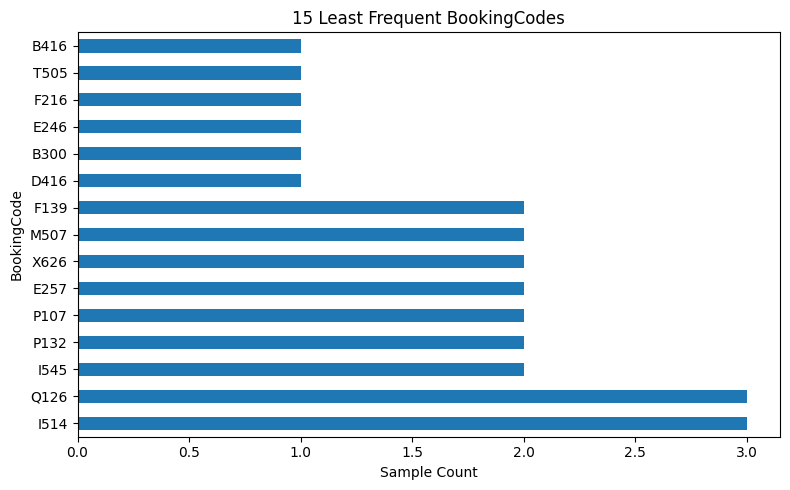

In [5]:
import matplotlib.pyplot as plt

ds['BookingCode'].value_counts().tail(15).plot(kind='barh', figsize=(8, 5), title='15 Least Frequent BookingCodes')
plt.xlabel('Sample Count')
plt.tight_layout()
plt.show()

In [6]:
# Drop labels with fewer than 2 samples in the full dataset
min_samples = 2
class_counts = ds["BookingCode"].value_counts()
valid_classes = class_counts[class_counts >= min_samples].index
ds_filtered = ds[ds["BookingCode"].isin(valid_classes)].copy()

print(f"Removed {len(ds) - len(ds_filtered)} rows with only 1 sample per class")
print(f"Remaining classes: {ds_filtered['BookingCode'].nunique()}")

Removed 6 rows with only 1 sample per class
Remaining classes: 94


## 3. Data splitting and label encoding
Splitt the dataset into train/validation and test and encoding the features

In [7]:
from sklearn.model_selection import train_test_split

# Feature (X) and label (y)
X = ds_filtered["Description"]
y = ds_filtered["BookingCode"]

# train (80%) and temp (20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

# validation and test dataset
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 2933, Val: 367, Test: 367


In [8]:
import tensorflow as tf


BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

# Build tf.data datasets from the splits
ds_train = tf.data.Dataset.from_tensor_slices((X_train.values, y_train.values))
ds_val   = tf.data.Dataset.from_tensor_slices((X_val.values,   y_val.values))
ds_test  = tf.data.Dataset.from_tensor_slices((X_test.values,  y_test.values))

ds_train = ds_train.shuffle(len(X_train)).batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_val   = ds_val.batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_test  = ds_test.batch(BATCH_SIZE).prefetch(AUTOTUNE)

I0000 00:00:1777467465.946971 1004918 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777467466.042507 1004918 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777467468.075928 1004918 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1777467468.615728 1004918 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries men

In [9]:
import numpy as np

# Build label vocabulary from filtered dataset
class_names = sorted(ds_filtered["BookingCode"].unique())
num_classes = len(class_names)
print("Number of classes:", num_classes)

# String -> int 
label_lookup = tf.keras.layers.StringLookup(
    vocabulary=class_names,
    output_mode="int",
    name="label_lookup")

# Encode labels inside the datasets (0-based indices)
def encode_labels(x, y):
    y_id = label_lookup(y) - 1
    return x, y_id

ds_train_enc = ds_train.map(encode_labels, num_parallel_calls=AUTOTUNE)
ds_val_enc   = ds_val.map(encode_labels,   num_parallel_calls=AUTOTUNE)
ds_test_enc  = ds_test.map(encode_labels,  num_parallel_calls=AUTOTUNE)

Number of classes: 94


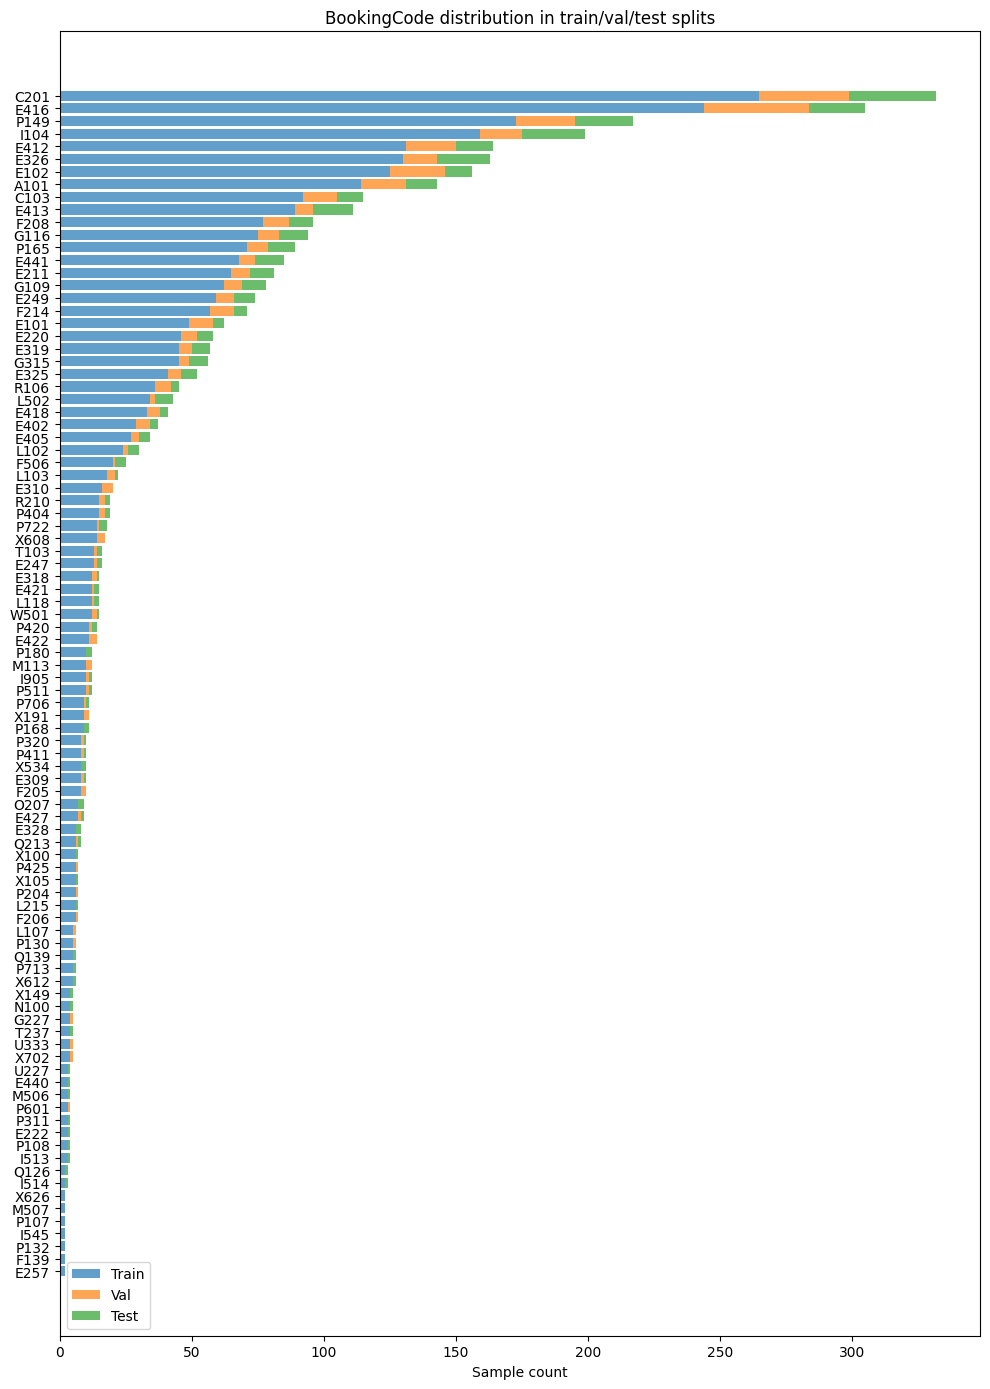

In [10]:
# plot the splitted datsets for differnet labels
from utils import plot_split_label_distribution

plot_split_label_distribution(y_train, y_val, y_test)

## Model selection and training


### M1:Baseline model (TextVectorization + Embedding multiclass model)

In [11]:
MAX_FEATURES = 20000
SEQ_LEN = 300

# Text vectorizer(handling tokenization and numericalization)
vectorize = tf.keras.layers.TextVectorization(
    max_tokens=MAX_FEATURES,
    output_mode="int",
    output_sequence_length=SEQ_LEN)

text_only_train = ds_train_enc.map(lambda x, y: x)#It only applied for training dataset
vectorize.adapt(text_only_train)

model_1 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,), dtype=tf.string),
    vectorize,
    tf.keras.layers.Embedding(MAX_FEATURES, 128),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation="softmax"),
])

model_1.compile(
    loss="sparse_categorical_crossentropy",  # integer labels
    optimizer="adam",
    metrics=["accuracy"],
)

model_1.summary()

import datetime as dt

log_dir = "Tensorboard_logs/model_1/" + dt.datetime.now().strftime("%Y%m%d-%H%M")

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1,
)

tensorboard_cb = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
)

history_1 = model_1.fit(
    ds_train_enc,
    validation_data=ds_val_enc,
    epochs=100,
    callbacks=[early_stopping, tensorboard_cb],
)

test_loss, test_acc = model_1.evaluate(ds_test_enc)
print("Test accuracy:", test_acc)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 300)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 300, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 94)             │         6,110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,574,366 (9.82 MB)

 Trainable params: 2,574,366 (9.82 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.0706 - loss: 4.1732 - val_accuracy: 0.1090 - val_loss: 3.7360
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0880 - loss: 3.8696 - val_accuracy: 0.1090 - val_loss: 3.6664
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.0750 - loss: 3.8152 - val_accuracy: 0.1090 - val_loss: 3.6502
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.0661 - loss: 3.8081 - val_accuracy: 0.0926 - val_loss: 3.6397
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.0825 - loss: 3.7828 - val_accuracy: 0.1090 - val_loss: 3.6535
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.0842 - loss: 3.7879 - val_accuracy: 0.0926 - val_loss: 3.6242
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0788 - loss: 3.7768 - val_accuracy: 0.0926 - val_loss: 3.6314
Epoch 8/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0784 - loss: 3.7784 - val_accuracy: 0.

### M2- CNN model

In [12]:
# CNN model

inputs = tf.keras.Input(shape=(1,), dtype=tf.string)
x = vectorize(inputs)
x = tf.keras.layers.Embedding(MAX_FEATURES, 128)(x)

conv_outputs = []
for k in [3, 4, 5]:
    c = tf.keras.layers.Conv1D(128, k, activation="relu")(x)
    c = tf.keras.layers.GlobalMaxPooling1D()(c)
    conv_outputs.append(c)

x = tf.keras.layers.Concatenate()(conv_outputs)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(64, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)

# MULTICLASS HEAD
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model_2 = tf.keras.Model(inputs, outputs)

model_2.compile(
    loss="sparse_categorical_crossentropy",  # integer labels
    optimizer="adam",
    metrics=["accuracy"],
)

# Callbacks
log_dir = "Tensorboard_logs/model_2/" + dt.datetime.now().strftime("%Y%m%d-%H%M")

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1,
)

tensorboard_cb = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
)

model_2.summary()

history_2 = model_2.fit(
    ds_train_enc,
    validation_data=ds_val_enc,
    epochs=100,
    callbacks=[early_stopping, tensorboard_cb],
)

test_loss, test_acc = model_2.evaluate(ds_test_enc)
print("Test accuracy:", test_acc)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 300)       │          0 │ input_layer_1[0]… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 300, 128)  │  2,560,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 298, 128)  │     49,280 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 297, 128)  │     65,664 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 296, 128)  │     82,048 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 384)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │     24,640 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 94)        │      6,110 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,787,742 (10.63 MB)

 Trainable params: 2,787,742 (10.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - accuracy: 0.0716 - loss: 4.2017 - val_accuracy: 0.1226 - val_loss: 3.5998
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.2083 - loss: 3.3953 - val_accuracy: 0.4278 - val_loss: 2.6181
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - accuracy: 0.3607 - loss: 2.6467 - val_accuracy: 0.5531 - val_loss: 1.9320
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - accuracy: 0.4807 - loss: 2.1206 - val_accuracy: 0.6512 - val_loss: 1.5455
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.5639 - loss: 1.7766 - val_accuracy: 0.6866 - val_loss: 1.3003
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.6198 - loss: 1.5354 - val_accuracy: 0.7330 - val_loss: 1.1545
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.6468 - loss: 1.3726 - val_accuracy: 0.7520 - val_loss: 1.0397
Epoch 8/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.6710 - loss: 1.2535 - val_accu

### M3- Universal Sentence Encoder (USE) from TensorFlow Hub

In [ ]:
import tensorflow_hub as hub
import numpy as np
import tensorflow as tf

#Model 3 doesn’t use the StringLookup layer, so I recreate the same class‑to‑ID mapping to get labels 0..num_classes‑1
# class_names already defined from ds_filtered
num_classes = len(class_names)

# Recreate a stable class-to-id mapping identical to label_lookup - 1
class_to_id = {c: i for i, c in enumerate(class_names)}

y_train_id = np.array([class_to_id[c] for c in y_train])
y_val_id   = np.array([class_to_id[c] for c in y_val])
y_test_id  = np.array([class_to_id[c] for c in y_test])

print(y_train_id.min(), y_train_id.max())  # should be 0 .. num_classes-1

encoder = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")

def encode_texts(texts):
    emb = encoder(texts.tolist())
    return emb.numpy()  #By default it will be (n, 512)

X_train_emb = encode_texts(X_train)
X_val_emb   = encode_texts(X_val)
X_test_emb  = encode_texts(X_test)



BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

def make_ds_from_emb(X_emb, y_ids, training=True):
    ds = tf.data.Dataset.from_tensor_slices((X_emb, y_ids))
    if training:
        ds = ds.shuffle(len(X_emb), reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

ds_train_use = make_ds_from_emb(X_train_emb, y_train_id, training=True)
ds_val_use   = make_ds_from_emb(X_val_emb,   y_val_id,   training=False)
ds_test_use  = make_ds_from_emb(X_test_emb,  y_test_id,  training=False)



inputs = tf.keras.Input(shape=(512,), dtype=tf.float32, name="use_embedding")
x = tf.keras.layers.Dropout(0.3)(inputs)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model_3 = tf.keras.Model(inputs, outputs)

model_3.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

model_3.summary()

import datetime as dt
log_dir = "Tensorboard_logs/model_3/" + dt.datetime.now().strftime("%Y%m%d-%H%M")

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1,
)

tensorboard_cb = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
)

history_3 = model_3.fit(
    ds_train_use,
    validation_data=ds_val_use,
    epochs=100,
    callbacks=[early_stopping, tensorboard_cb],
    verbose=2,
)

test_loss, test_acc = model_3.evaluate(ds_test_use)
print("Test accuracy:", test_acc)

/home/paminidigehsara/Desktop/controlEx_prep/.venv_ce/lib/python3.12/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


0 93


E0000 00:00:1777467781.975739 1004918 util.cc:131] oneDNN supports DT_INT64 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ use_embedding (InputLayer)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 94)             │        12,126 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,790 (303.87 KB)

 Trainable params: 77,790 (303.87 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
46/46 - 2s - 34ms/step - accuracy: 0.1817 - loss: 4.2428 - val_accuracy: 0.2861 - val_loss: 3.6782
Epoch 2/100
46/46 - 0s - 8ms/step - accuracy: 0.2714 - loss: 3.3091 - val_accuracy: 0.4060 - val_loss: 2.7836
Epoch 3/100
46/46 - 0s - 8ms/step - accuracy: 0.3890 - loss: 2.7677 - val_accuracy: 0.4905 - val_loss: 2.3469
Epoch 4/100
46/46 - 0s - 8ms/step - accuracy: 0.4337 - loss: 2.4310 - val_accuracy: 0.5450 - val_loss: 2.0378
Epoch 5/100
46/46 - 0s - 8ms/step - accuracy: 0.4991 - loss: 2.1861 - val_accuracy: 0.6076 - val_loss: 1.8187
Epoch 6/100
46/46 - 0s - 8ms/step - accuracy: 0.5329 - loss: 2.0056 - val_accuracy: 0.6403 - val_loss: 1.6547
Epoch 7/100
46/46 - 0s - 8ms/step - accuracy: 0.5612 - loss: 1.8478 - val_accuracy: 0.6594 - val_loss: 1.5259
Epoch 8/100
46/46 - 0s - 8ms/step - accuracy: 0.5704 - loss: 1.7271 - val_accuracy: 0.6730 - val_loss: 1.4268
Epoch 9/100
46/46 - 0s - 8ms/step - accuracy: 0.5885 - loss: 1.6337 - val_accuracy: 0.6894 - val_loss: 1.3458
Epoch 10/

## 5. Results

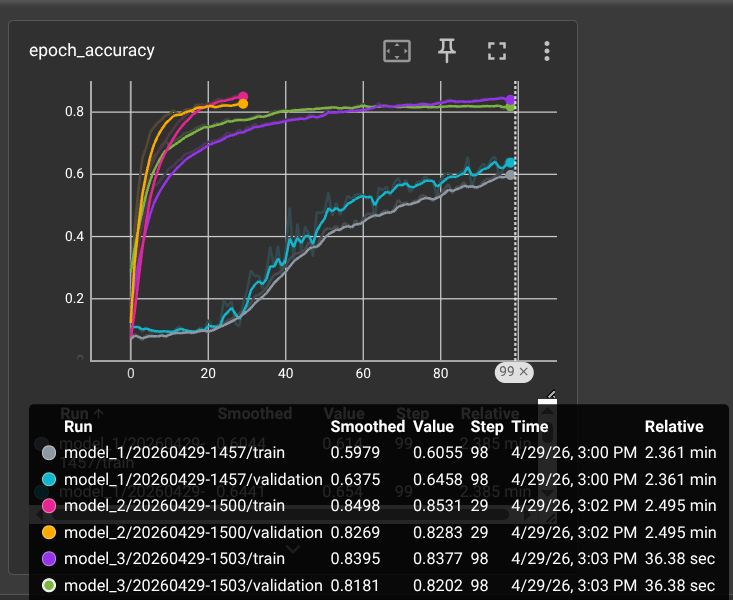

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


/tmp/ipykernel_1004918/493217215.py:17: RuntimeWarning: invalid value encountered in divide
  cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)


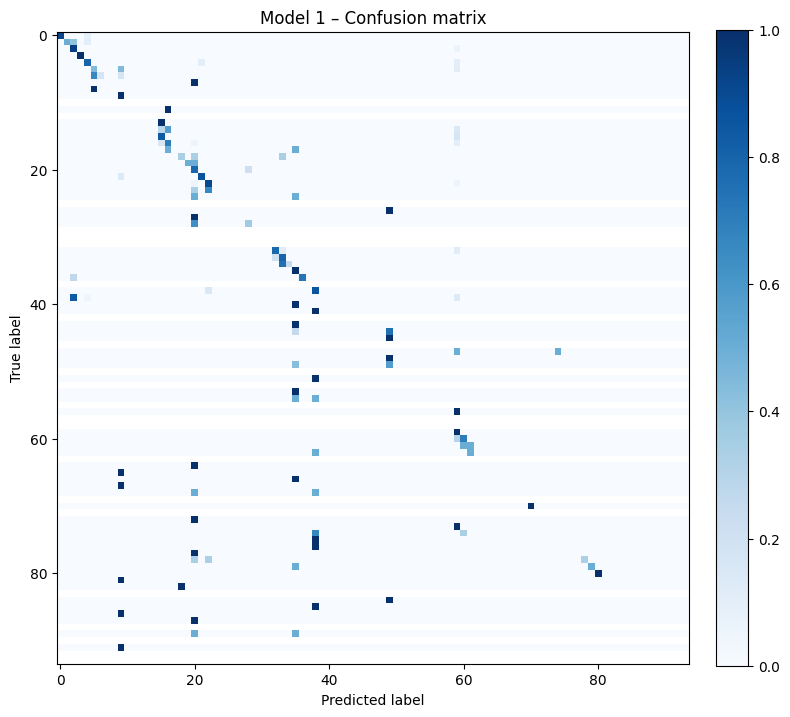

/tmp/ipykernel_1004918/493217215.py:17: RuntimeWarning: invalid value encountered in divide
  cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)


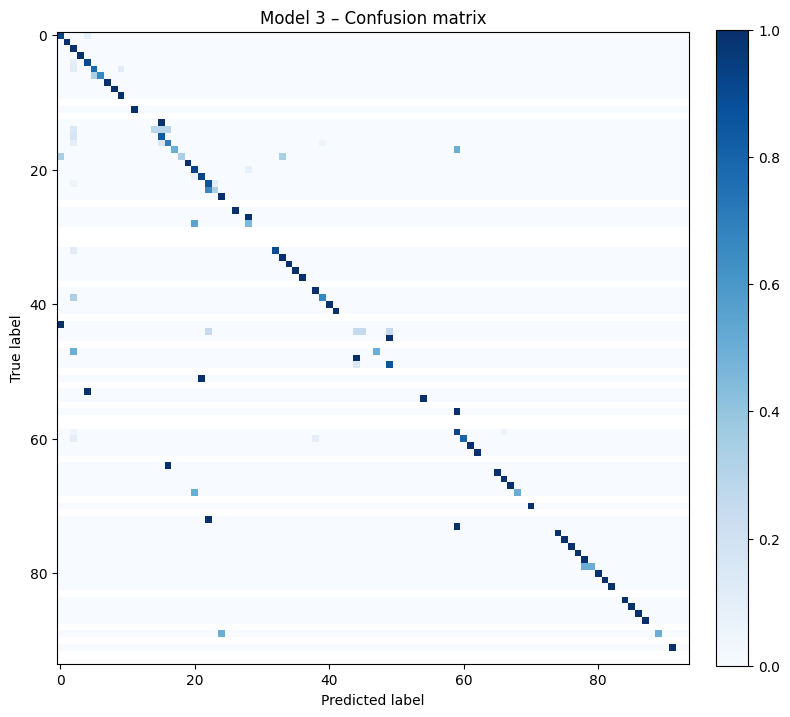

In [20]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1) Get y_true as integer IDs (you already have y_test_id)
y_true = y_test_id  # shape (n_test,)

# 2) Get predicted class IDs for each model
# Model 1 & 2 work on dstest_enc, model 3 on ds_test_use
y_pred_m1 = np.argmax(model_1.predict(ds_test_enc), axis=1)
y_pred_m2 = np.argmax(model_2.predict(ds_test_enc), axis=1)
y_pred_m3 = np.argmax(model_3.predict(ds_test_use), axis=1)

def plot_confusion_matrix(cm, class_names, title, normalize=False, figsize=(8, 8)):
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    
    plt.figure(figsize=figsize)
    im = plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar(im, fraction=0.046, pad=0.04)

    # Only show a subset of labels to keep it readable with 94 classes
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

# Model 1
cm1 = confusion_matrix(y_true, y_pred_m1, labels=np.arange(num_classes))
plot_confusion_matrix(cm1, class_names, title="Model 1 – Confusion matrix", normalize=True)

# # Model 2
# cm2 = confusion_matrix(y_true, y_pred_m2, labels=np.arange(num_classes))
# plot_confusion_matrix(cm2, class_names, title="Model 2 – Confusion matrix", normalize=True)

# Model 3
cm3 = confusion_matrix(y_true, y_pred_m3, labels=np.arange(num_classes))
plot_confusion_matrix(cm3, class_names, title="Model 3 – Confusion matrix", normalize=True)

In [ ]:
import numpy as np

y_true = y_test_id

y_pred_m1 = np.argmax(model_1.predict(ds_test_enc), axis=1)
y_pred_m2 = np.argmax(model_2.predict(ds_test_enc), axis=1)
y_pred_m3 = np.argmax(model_3.predict(ds_test_use), axis=1)

from sklearn.metrics import accuracy_score, f1_score, classification_report

def eval_model(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")     # treats all classes equally[web:97][web:99]
    f1_weighted = f1_score(y_true, y_pred, average="weighted")  # weights by class frequency[web:97][web:99]

    print(f"=== {name} ===")
    print(f"Accuracy      : {acc:.3f}")
    print(f"Macro F1      : {f1_macro:.3f}")
    print(f"Weighted F1   : {f1_weighted:.3f}")
    print()

    # Optional: full report (will be long with 94 classes)
    # print(classification_report(y_true, y_pred, digits=3))

    
eval_model(y_true, y_pred_m1, "Model 1 – Avg embedding baseline")
eval_model(y_true, y_pred_m2, "Model 2 – CNN")
eval_model(y_true, y_pred_m3, "Model 3 – USE")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
=== Model 1 – Avg embedding baseline ===
Accuracy      : 0.586
Macro F1      : 0.273
Weighted F1   : 0.515

=== Model 2 – CNN ===
Accuracy      : 0.807
Macro F1      : 0.648
Weighted F1   : 0.793

=== Model 3 – USE ===
Accuracy      : 0.820
Macro F1      : 0.735
Weighted F1   : 0.805



In [16]:
%load_ext tensorboard
# %tensorboard --logdir Tensorboard_logs/ #in a terminal

## Future works

**Richer inputs**: Add simple structured features (e.g., Count, SumPrice, workshop ID) alongside the description text and measure the effect on macro‑F1.

**Stronger encoders**: Replace USE with a small, fine‑tuned transformer encoder   

**Better handling of imbalance**: Try class‑weighted and use confusion matrices to check whether recall for under‑represented booking codes improves.

**Classical models**: like SVM family adn etc.